# Task

Create a convolutional neural network to process the MNIST dataset.

Compare it with a neural network with fully connected layers.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Load and display data

In [4]:
from keras.datasets import mnist
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

Reminder that values take on shades of grey 0 - 255
* 0 is black
* 255 is white

In [5]:
img = X_train[0]
print (f"min:{np.amin(X_train[0])} max:{np.amax(X_train[0])}")

min:0 max:255


In [6]:
def show_images (images, labels, rows=6, cols=10):
    fig, axes = plt.subplots(rows, cols, figsize=(cols, rows))
    for idx in range (0, rows * cols):
        ridx=idx // cols
        cidx=idx % cols
        ax= axes[ridx, cidx]
        ax.axis("off")
        ax.imshow(images[idx], cmap="gray_r")
        ax.set_title(f"{labels[idx]}")
    plt.show()    

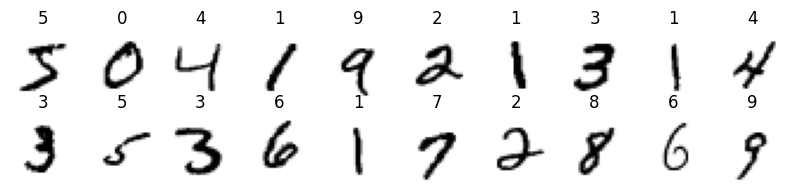

In [7]:
show_images(X_train, Y_train, 2, 10)

# Data preparation

Standardization of values from range 0 - 255 to range 0 - 1

In [8]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

Binary encoding

In [9]:
from keras.utils import to_categorical 
Y_train = to_categorical(Y_train, num_classes=10)
Y_test = to_categorical(Y_test, num_classes=10)

# Neural network

In [16]:
import keras
from keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, Flatten
from keras.models import Sequential
from sklearn.metrics import r2_score, confusion_matrix


In [18]:

X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

model_cnn = Sequential()
model_cnn.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28, 28, 1)))
model_cnn.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))
model_cnn.add(Dropout(0.25))

model_cnn.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model_cnn.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model_cnn.add(MaxPooling2D(pool_size=(2,2)))
model_cnn.add(Dropout(0.25))

model_cnn.add(Flatten())
model_cnn.add(Dense(128, activation='relu'))
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(10, activation='softmax'))

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_cnn = time.time()
history_cnn = model_cnn.fit(X_train_cnn, Y_train, batch_size=64, epochs=10, verbose=1)
time_cnn = time.time() - start_cnn

model_cnn.save('classification_model_mnist_cnn.keras')

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.9238 - loss: 0.2392
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9764 - loss: 0.0830
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9833 - loss: 0.0570
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9858 - loss: 0.0495
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9869 - loss: 0.0427
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9882 - loss: 0.0390
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9899 - loss: 0.0339
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9905 - loss: 0.0311
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.9916 - loss: 0.0286
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.9914 - loss: 0.0281


In [20]:
# DENSE MODEL

X_train_dense = X_train.reshape(-1, 784)
X_test_dense = X_test.reshape(-1, 784)

model_dense = Sequential()
model_dense.add(Dense(512, activation='relu', input_shape=(784,)))
model_dense.add(Dropout(0.3))
model_dense.add(Dense(256, activation='relu'))
model_dense.add(Dropout(0.3))
model_dense.add(Dense(10, activation='softmax'))

model_dense.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_dense = time.time()
history_dense = model_dense.fit(X_train_dense, Y_train, batch_size=64, epochs=10, verbose=1)
time_dense = time.time() - start_dense

model_dense.save('classification_model_mnist_dense.keras')

Epoch 1/10


d:\exercises-Ylyzaveta\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9197 - loss: 0.2622
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9626 - loss: 0.1228
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9714 - loss: 0.0910
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9765 - loss: 0.0763
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9790 - loss: 0.0657
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9815 - loss: 0.0578
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9835 - loss: 0.0510
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9841 - loss: 0.0477
Epoch 9/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9861 - loss: 0.0444
Epoch 10/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9874 - loss: 0.0400


# History of learning model
- Show learning curve
- Show model accuracy curve
- Describe the shapes

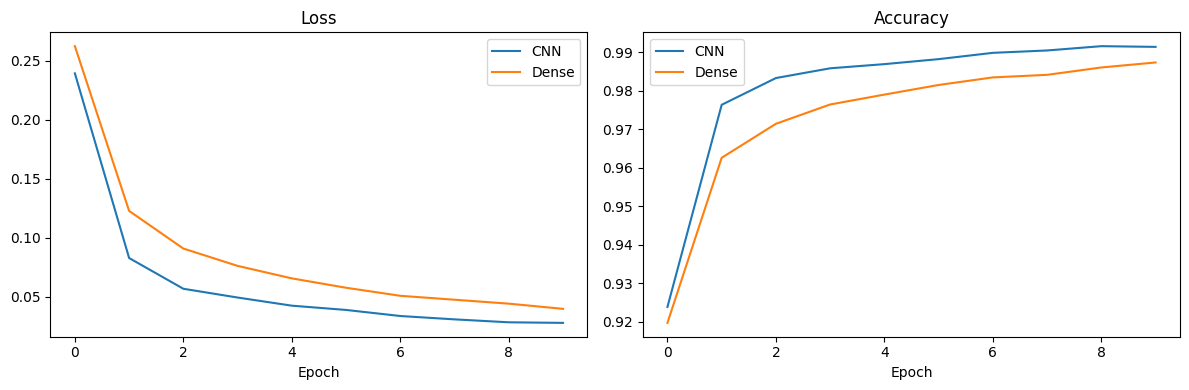


Curve description:
- CNN converges faster with smoother curves
- Dense has more fluctuations but reaches similar accuracy


In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['loss'], label='CNN')
plt.plot(history_dense.history['loss'], label='Dense')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['accuracy'], label='CNN')
plt.plot(history_dense.history['accuracy'], label='Dense')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

print("\nCurve description:")
print("- CNN converges faster with smoother curves")
print("- Dense has more fluctuations but reaches similar accuracy")

# Model Verification
- R2 score
- Accuracy of the model as a whole
- Accuracy across classes
- Change matrix
- Examples of misclassification


R2 score:
CNN:   0.9888
Dense: 0.9534

Accuracy:
CNN:   0.9945
Dense: 0.9815

Accuracy per class:
0: CNN 99.80%, Dense 99.39%
1: CNN 99.65%, Dense 98.94%
2: CNN 99.90%, Dense 98.55%
3: CNN 99.60%, Dense 97.52%
4: CNN 99.19%, Dense 98.17%
5: CNN 99.55%, Dense 96.41%
6: CNN 99.06%, Dense 98.75%
7: CNN 98.83%, Dense 98.05%
8: CNN 99.38%, Dense 98.15%
9: CNN 99.50%, Dense 97.32%


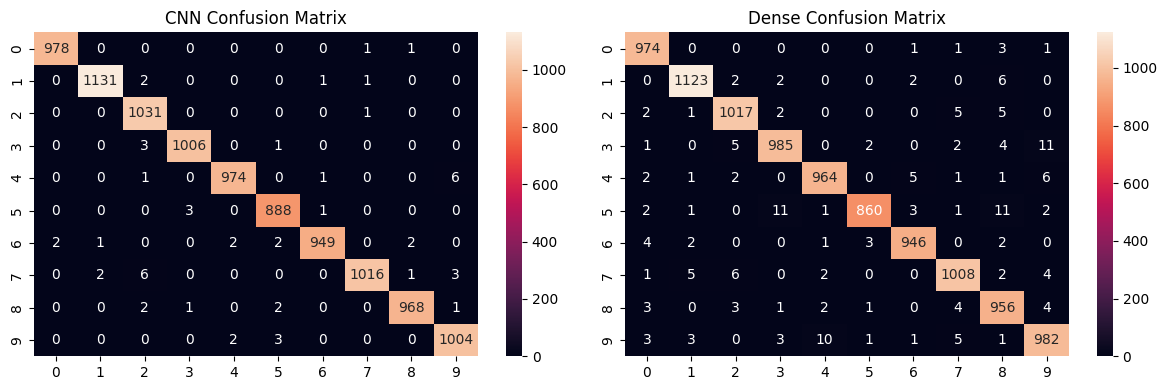

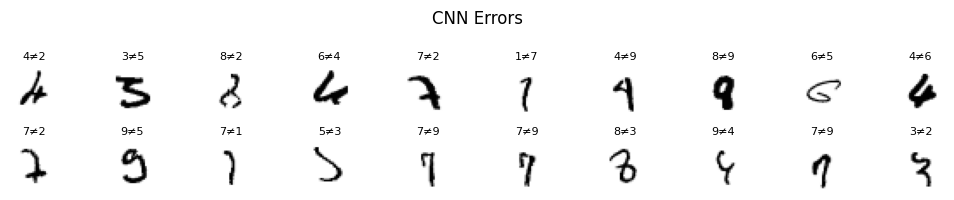

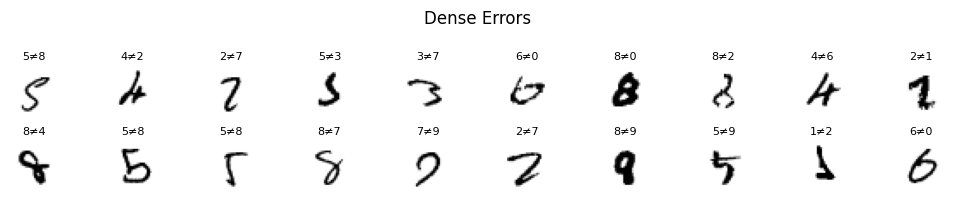

In [22]:
# Predictions
start_inf_cnn = time.time()
Y_pred_cnn = model_cnn.predict(X_test_cnn, verbose=0)
inf_time_cnn = time.time() - start_inf_cnn

start_inf_dense = time.time()
Y_pred_dense = model_dense.predict(X_test_dense, verbose=0)
inf_time_dense = time.time() - start_inf_dense

Y_pred_cnn = np.argmax(Y_pred_cnn, axis=-1)
Y_pred_dense = np.argmax(Y_pred_dense, axis=-1)
Y_test_true = np.argmax(Y_test, axis=-1)

# R2 score
print("\nR2 score:")
print(f"CNN:   {r2_score(Y_test_true, Y_pred_cnn):.4f}")
print(f"Dense: {r2_score(Y_test_true, Y_pred_dense):.4f}")

# Accuracy
scores_cnn = model_cnn.evaluate(X_test_cnn, Y_test, verbose=0)
scores_dense = model_dense.evaluate(X_test_dense, Y_test, verbose=0)

print("\nAccuracy:")
print(f"CNN:   {scores_cnn[1]:.4f}")
print(f"Dense: {scores_dense[1]:.4f}")

# Accuracy across classes
print("\nAccuracy per class:")
for i in range(10):
    mask_cnn = Y_pred_cnn[Y_test_true == i] == i
    mask_dense = Y_pred_dense[Y_test_true == i] == i
    print(f"{i}: CNN {mask_cnn.mean():.2%}, Dense {mask_dense.mean():.2%}")

# Confusion matrix
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(Y_test_true, Y_pred_cnn), annot=True, fmt='d')
plt.title('CNN Confusion Matrix')

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(Y_test_true, Y_pred_dense), annot=True, fmt='d')
plt.title('Dense Confusion Matrix')

plt.tight_layout()
plt.show()

# Misclassifications
def show_errors(X, Y_true, Y_pred, title):
    errors = np.where(Y_true != Y_pred)[0][:20]
    fig, axes = plt.subplots(2, 10, figsize=(10, 2))
    for i, idx in enumerate(errors):
        ax = axes[i//10, i%10]
        ax.imshow(X[idx].reshape(28, 28), cmap='gray_r')
        ax.set_title(f"{Y_true[idx]}≠{Y_pred[idx]}", fontsize=8)
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_errors(X_test, Y_test_true, Y_pred_cnn, 'CNN Errors')
show_errors(X_test, Y_test_true, Y_pred_dense, 'Dense Errors')

# Model Comparison
- Which model is more accurate
- How about the learning time
- How about the time of inference

In [23]:
print(f"\nAccuracy:        CNN {scores_cnn[1]:.2%} vs Dense {scores_dense[1]:.2%}")
print(f"Training time:   CNN {time_cnn:.1f}s vs Dense {time_dense:.1f}s")
print(f"Inference time:  CNN {inf_time_cnn:.3f}s vs Dense {inf_time_dense:.3f}s")
print(f"\n→ CNN is {'more' if scores_cnn[1] > scores_dense[1] else 'less'} accurate")
print(f"→ CNN trains {'faster' if time_cnn < time_dense else 'slower'}")
print(f"→ CNN inference is {'faster' if inf_time_cnn < inf_time_dense else 'slower'}")


Accuracy:        CNN 99.45% vs Dense 98.15%
Training time:   CNN 212.9s vs Dense 28.3s
Inference time:  CNN 4.954s vs Dense 1.354s

→ CNN is more accurate
→ CNN trains slower
→ CNN inference is slower
